# 2 - HCP model fitting and evaluation

This notebook fits neural-network dynamical models to the preprocessed HCP resting-state fMRI data generated in `HCP_1_Process_data`.

This notebook assumes that `HCP_1_Process_data.ipynb` has already been run and that the processed arrays are available in the preprocessing output folder.

For each selected subject, the notebook:

1. Loads `inputs` and `targets`
2. Builds the selected model architecture
3. Trains the model to predict the next fMRI time point
4. Saves the trained model and loss curves
5. Simulates time series from the trained model
6. Compares empirical and simulated dynamics using:
   - time-series visualizations
   - static functional connectivity (FC)
   - dynamic functional connectivity (dFC)
   - group-level summary metrics
    
## Saved outputs

For each subject, the notebook saves a trained model:

- `trained_models_<METHOD>/<SUBJECT>_<METHOD>.pt`

It also saves a summary dictionary:

- `ANN_results_<METHOD>.npy`

containing:
- training loss
- testing loss
- model type
- number of regions
- number of input steps

In [1]:
from pathlib import Path
import sys
import os
import gc
import shutil
import numpy as np
import matplotlib.pyplot as plt
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
from scipy import stats
from scipy.stats import ks_2samp, pearsonr, linregress
from matplotlib.transforms import Affine2D
from matplotlib.patches import Polygon
import torch.serialization

# -----------------------------------------------------------------------------
# Path and environment configuration
# -----------------------------------------------------------------------------
# Supported execution modes:
# 1. Local repository execution
# 2. Google Colab execution with optional Drive mounting
#
# Expected structure after preprocessing:
#
# Projects/
# └── BrainStim_ANN_fMRI_HCP/
#     ├── src/
#     ├── notebooks/
#     └── Results/
#         └── processed/

repo_dir = Path.cwd().resolve().parent
data_dir = repo_dir / "Results"
preproc_dir = data_dir / "processed"
save_dir = data_dir / "ANN_model"

sys.path.insert(0, str(repo_dir))

from src import NPI

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Repository directory :", repo_dir)
print("Processed data dir   :", preproc_dir)
print("Save directory       :", save_dir)
print("PyTorch version      :", torch.__version__)
print("CUDA available       :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Running on           :", torch.cuda.get_device_name(0))
else:
    print("Running on           : CPU")

Repository directory : C:\Users\tomas\Documents\PhD\Projects\BrainStim
Processed data dir   : C:\Users\tomas\Documents\PhD\Projects\BrainStim\Results\processed
Save directory       : C:\Users\tomas\Documents\PhD\Projects\BrainStim\Results\ANN_model
PyTorch version      : 2.5.1
CUDA available       : False
Running on           : CPU


In [2]:
# =============================================================================
# Fitting parameters
# =============================================================================
method = "MLP"              # options: "MLP", "CNN", "RNN", "VAR"

ROI_num = 450               # number of brain regions/parcels
using_steps = 3             # sliding-window length used during preprocessing
batch_size = 64
train_set_proportion = 0.90
num_epochs = 50
learning_rate = 5e-4
l2_reg = 5e-5

print("Training configuration:")
print("  Method               :", method)
print("  Number of regions    :", ROI_num)
print("  Window length        :", using_steps)
print("  Training proportion  :", train_set_proportion)
print("  Epochs               :", num_epochs)
print("  Batch size           :", batch_size)
print("  Learning rate        :", learning_rate)
print("  L2 regularization    :", l2_reg)

Training configuration:
  Method               : MLP
  Number of regions    : 450
  Window length        : 3
  Training proportion  : 0.9
  Epochs               : 50
  Batch size           : 64
  Learning rate        : 0.0005
  L2 regularization    : 5e-05


In [3]:
# =============================================================================
# Locate processed subject files
# =============================================================================
signal_files = sorted(preproc_dir.glob("*_signals.npy"))
input_files  = sorted(preproc_dir.glob("*_inputs.npy"))
target_files = sorted(preproc_dir.glob("*_targets.npy"))

subject_ids = sorted({p.name.split("_signals.npy")[0] for p in signal_files})
subject_ids = [sid for sid in subject_ids
               if (preproc_dir / f"{sid}_inputs.npy").exists()
               and (preproc_dir / f"{sid}_targets.npy").exists()]

print(f"Subjects with complete processed data: {len(subject_ids)}")
if len(subject_ids) > 0:
    pass
else:
    print("No processed subjects found. Run HCP_1_Process_data first or check preproc_dir.")

Subjects with complete processed data: 100


In [4]:
# =============================================================================
# Main fitting loop
# =============================================================================
results = {}

for sid in subject_ids:
    model_path = save_dir / f"{sid}_{method}.pt"
    subject_results_path = save_dir / f"{sid}_{method}_results.npy"

    # Skip subject if fitted model already exists
    if model_path.exists():
        #print(f"\nSkipping subject {sid}: model already exists at {model_path}")
        continue

    print(f"\nTraining subject {sid} with {method}")

    inputs = np.load(preproc_dir / f"{sid}_inputs.npy")
    targets = np.load(preproc_dir / f"{sid}_targets.npy")

    model = NPI.build_model(method, ROI_num, using_steps)
    model, train_loss, test_loss = NPI.train_NN(
        model,
        inputs,
        targets,
        batch_size=batch_size,
        train_set_proportion=train_set_proportion,
        num_epochs=num_epochs,
        lr=learning_rate,
        l2=l2_reg,
    )

    torch.save(model, model_path)

    subject_results = {
        "subject_id": sid,
        "train_loss": train_loss,
        "test_loss": test_loss,
        "method": method,
        "ROI_num": ROI_num,
        "using_steps": using_steps,
    }

    np.save(subject_results_path, subject_results, allow_pickle=True)

    print(f"  Final test loss: {test_loss[-1]:.6f}")
    print(f"  Saved model to : {model_path}")

    del inputs, targets, model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nFitting complete.")


Fitting complete.


## Model loading and evaluation utilities

The following cells:
- load trained models safely
- visualize training curves
- simulate empirical-length time series
- compare empirical and simulated FC and dFC

In [5]:
# Allowlist model classes for recent PyTorch versions
torch.serialization.add_safe_globals(
    [NPI.ANN_MLP, NPI.ANN_CNN, NPI.ANN_RNN, NPI.ANN_VAR]
)

def load_model(model_path, inputs=None, targets=None):
    """Load either a full serialized model or a state-dict checkpoint."""
    ckpt = torch.load(model_path, map_location=device, weights_only=False)

    if hasattr(ckpt, "eval"):
        model = ckpt.to(device)
        model.eval()
        return model

    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        method_ckpt = ckpt.get("method", method)
        roi_ckpt = ckpt.get("ROI_num", targets.shape[-1] if targets is not None else ROI_num)
        steps_ckpt = ckpt.get("using_steps", using_steps)
        model = NPI.build_model(method_ckpt, roi_ckpt, steps_ckpt).to(device)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()
        return model

    raise ValueError("Unrecognized model format.")
    
def go_edge(tseries):
    """Edge time series from z-scored regional signals."""
    nregions = tseries.shape[1]
    i_tri = np.triu_indices(nregions, k=1)
    gz = stats.zscore(tseries, axis=0)
    return gz[:, i_tri[0]] * gz[:, i_tri[1]]

def dFC(tseries):
    """Dynamic FC matrix from edge time series."""
    return np.corrcoef(go_edge(tseries))

def available_subjects():
    return sorted({p.name.split("_signals.npy")[0] for p in preproc_dir.glob("*_signals.npy")})

def plot_split_matrix(mat_left, mat_right, title, left_label="Empirical", right_label="Model",
                      cmap="plasma", vmin=0.0, vmax=1.0, axis_label="ROIs", figsize=(2.8, 2.8)):
    """Plot two square matrices as left/right rotated triangular halves."""
    extent = (-1, 1, -1, 1)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal")
    ax.set_axis_off()

    rot = Affine2D().rotate_deg(45) + ax.transData

    im_left = ax.imshow(mat_left, origin="lower", extent=extent, vmin=vmin, vmax=vmax,
                        cmap=cmap, transform=rot, interpolation="nearest")
    clip_left = Polygon([(-1, 0), (0, 1), (0, -1)], closed=True,
                        facecolor="none", edgecolor="none", transform=ax.transData)
    im_left.set_clip_path(clip_left)

    im_right = ax.imshow(mat_right, origin="lower", extent=extent, vmin=vmin, vmax=vmax,
                         cmap=cmap, transform=rot, interpolation="nearest")
    clip_right = Polygon([(0, -1), (0, 1), (1, 0)], closed=True,
                         facecolor="none", edgecolor="none", transform=ax.transData)
    im_right.set_clip_path(clip_right)

    ax.plot([0, 0], [-1, 1], color="w", lw=2)
    ax.text(0.0, 1.2, title, color="k", ha="center", va="center", fontsize=12)
    ax.text(-0.5, 1.0, left_label, color="k", ha="center", va="center", fontsize=10)
    ax.text(0.5, 1.0, right_label, color="k", ha="center", va="center", fontsize=10)
    ax.text(-0.6, -0.6, axis_label, ha="center", va="center", fontsize=10, rotation=-45)
    ax.text(0.6, -0.6, axis_label, ha="center", va="center", fontsize=10, rotation=45)

    plt.tight_layout()
    plt.show()
    
def format_p_scientific(p):
    if p == 0:
        return r"$p < 1\times 10^{-308}$"
    exponent = int(np.floor(np.log10(p)))
    mantissa = p / 10**exponent
    return rf"$p = {mantissa:.2f}\times 10^{{{exponent}}}$"

def fitted_subjects(method=method):
    """Subjects with both a trained model and a per-subject results file."""
    fitted = []
    for sid in available_subjects():
        model_path = save_dir / f"{sid}_{method}.pt"
        result_path = save_dir / f"{sid}_{method}_results.npy"
        if model_path.exists() and result_path.exists():
            fitted.append(sid)
    return fitted


Loaded results for 100 fitted subjects.


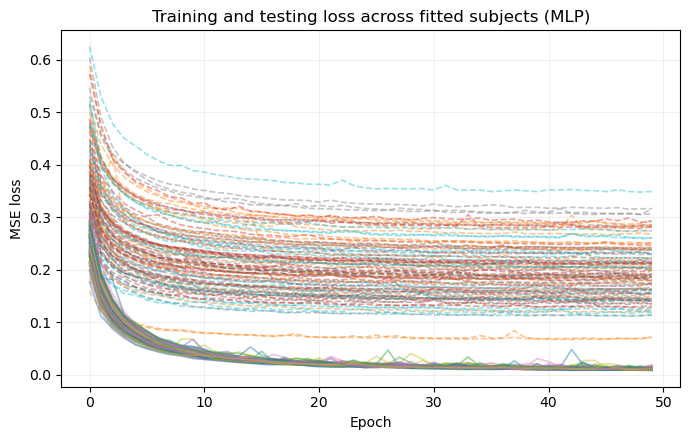

In [6]:
# =============================================================================
# Visualize learning curves
# =============================================================================
method = "MLP"  # or whatever you used: 'TCN', 'RNN', etc.

for result_path in sorted(save_dir.glob(f"*_{method}_results.npy")):
        subject_result = np.load(result_path, allow_pickle=True).item()
        sid = str(subject_result.get("subject_id", result_path.stem.replace(f"_{method}_results", "")))
        results[sid] = subject_result

if len(results) == 0:
    print(f"No per-subject results found in: {results_dir}")
else:
    print(f"Loaded results for {len(results)} fitted subjects.")

    plt.figure(figsize=(7.0, 4.5))
    for sid, vals in results.items():
        plt.plot(vals["train_loss"], alpha=0.45, linewidth=1.2)
        plt.plot(vals["test_loss"], linestyle="--", alpha=0.45, linewidth=1.2)

    plt.title(f"Training and testing loss across fitted subjects ({method})")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


## Single-subject simulation and comparison

In [7]:
fitted = fitted_subjects(method=method)
subjects = fitted
subject_to_plot = subjects[0]

sig_path = preproc_dir / f"{subject_to_plot}_signals.npy"
inp_path = preproc_dir / f"{subject_to_plot}_inputs.npy"
tgt_path = preproc_dir / f"{subject_to_plot}_targets.npy"
mdl_path = save_dir / f"{subject_to_plot}_{method}.pt"

Z = np.load(sig_path)
X = np.load(inp_path)
Y = np.load(tgt_path)

model = load_model(mdl_path, X, Y)

S = using_steps
N = Z.shape[1]
Zsim = NPI.model_time_series(model, np.zeros((S, N)), tlen=4600, noise_strength=0.1)

print("Subject             :", subject_to_plot)
print("Empirical shape     :", Z.shape)
print("Inputs shape        :", X.shape)
print("Targets shape       :", Y.shape)
print("Simulated shape     :", Zsim.shape)

Subject             : id_100206
Empirical shape     : (4680, 450)
Inputs shape        : (4677, 1350)
Targets shape       : (4677, 450)
Simulated shape     : (4603, 450)


In [8]:
# =============================================================================
# Compare empirical and simulated dynamics for one subject
# =============================================================================
test_dur = 3000

emp = Z[-test_dur:, :]
sim = Zsim[-test_dur:, :]

FC_emp = np.corrcoef(emp.T)
FC_sim = np.corrcoef(sim.T)

dFC_emp = dFC(emp)
dFC_sim = dFC(sim)

print("FC shape  :", FC_emp.shape)
print("dFC shape :", dFC_emp.shape)

FC shape  : (450, 450)
dFC shape : (3000, 3000)


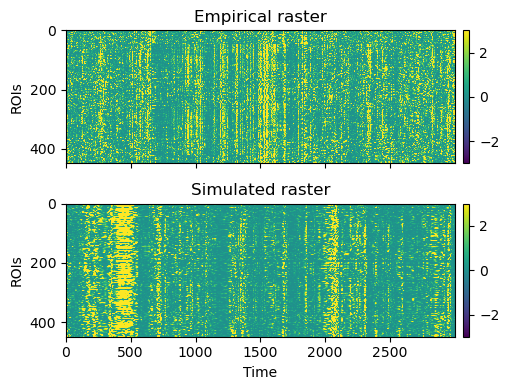

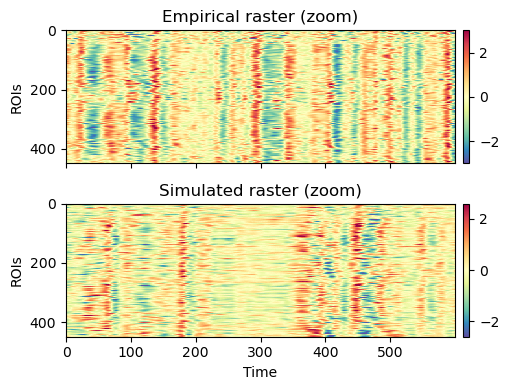

In [9]:
# =============================================================================
# Raster visualizations
# =============================================================================
fig, axes = plt.subplots(2, 1, figsize=(5.2, 4.0), sharex=True)

axes[0].set_title("Empirical raster")
im0 = axes[0].imshow((stats.zscore(emp, axis=0) ** 2).T, aspect="auto",
                     vmin=-3, vmax=3, cmap="viridis", interpolation="nearest")
axes[0].set_ylabel("ROIs")
plt.colorbar(im0, ax=axes[0], fraction=0.025, pad=0.02)

axes[1].set_title("Simulated raster")
im1 = axes[1].imshow((stats.zscore(sim, axis=0) ** 2).T, aspect="auto",
                     vmin=-3, vmax=3, cmap="viridis", interpolation="nearest")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("ROIs")
plt.colorbar(im1, ax=axes[1], fraction=0.025, pad=0.02)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(5.2, 4.0), sharex=True)
zoom_slice = slice(900, 1500)

axes[0].set_title("Empirical raster (zoom)")
im0 = axes[0].imshow(stats.zscore(emp, axis=0)[zoom_slice, :].T, aspect="auto",
                     vmin=-3.0, vmax=3.0, cmap="Spectral_r", interpolation="nearest")
axes[0].set_ylabel("ROIs")
plt.colorbar(im0, ax=axes[0], fraction=0.025, pad=0.02)

axes[1].set_title("Simulated raster (zoom)")
im1 = axes[1].imshow(stats.zscore(sim, axis=0)[zoom_slice, :].T, aspect="auto",
                     vmin=-2.6, vmax=2.6, cmap="Spectral_r", interpolation="nearest")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("ROIs")
plt.colorbar(im1, ax=axes[1], fraction=0.025, pad=0.02)

plt.tight_layout()
plt.show()

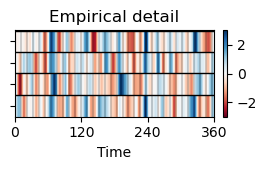

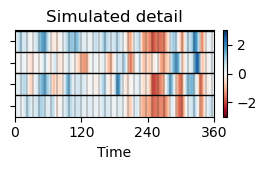

In [10]:
# =============================================================================
# Fine-grained signal example (last 4 regions)
# =============================================================================
dura = 501

for data, title in [(emp, "Empirical detail"), (sim, "Simulated detail")]:
    plt.figure(figsize=(2.8, 1.8))
    plt.imshow(stats.zscore(data, axis=0)[-dura:, -4:].T,
               aspect="auto", vmin=-3, vmax=3, cmap="RdBu", interpolation="nearest")
    for y in [-0.49, 0.49, 1.49, 2.49]:
        plt.axhline(y, linewidth=1, c="k")
    for i in np.arange(dura)[::15]:
        plt.axvline(i + 0.5, linewidth=0.25, c="k")
    plt.title(title)
    plt.xlabel("Time")
    plt.yticks([0, 1, 2, 3], ["", "", "", ""])
    plt.xticks([0, dura / 3, 2 * dura / 3, dura],
               [0, int(dura / 3 * 0.72), int(2 * dura / 3 * 0.72), int(dura * 0.72)])
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


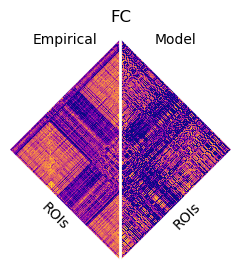

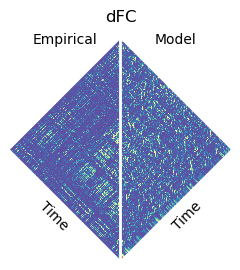

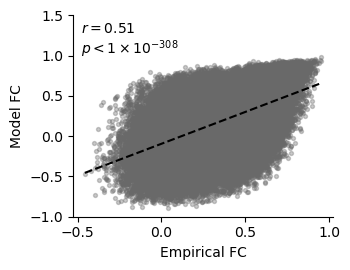

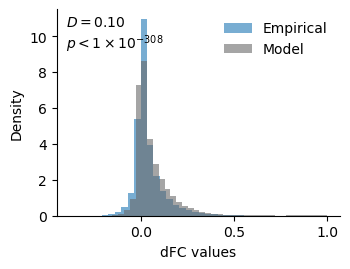

In [11]:
# =============================================================================
# Static FC and dynamic FC comparisons
# =============================================================================
plot_split_matrix(FC_emp, FC_sim, title="FC", cmap="plasma", vmin=0.0, vmax=1.0, axis_label="ROIs")
plot_split_matrix(dFC_emp, dFC_sim, title="dFC", cmap="Spectral_r", vmin=0.0, vmax=1.0, axis_label="Time")

# FC scatter
tri_fc = np.triu_indices_from(FC_emp, k=1)
x_fc = FC_emp[tri_fc].astype(float).ravel()
y_fc = FC_sim[tri_fc].astype(float).ravel()
m_fc = np.isfinite(x_fc) & np.isfinite(y_fc)
x_fc, y_fc = x_fc[m_fc], y_fc[m_fc]

r_fc, p_fc = pearsonr(x_fc, y_fc)
lr_fc = linregress(x_fc, y_fc)

fig, ax = plt.subplots(figsize=(3.6, 2.8))
ax.scatter(x_fc, y_fc, s=8, alpha=0.35, c="dimgray")
xx = np.linspace(x_fc.min(), x_fc.max(), 200)
ax.plot(xx, lr_fc.slope * xx + lr_fc.intercept, linewidth=1.5, c="k", linestyle="--")
ax.set_xlabel("Empirical FC")
ax.set_ylabel("Model FC")
ax.text(0.03, 0.97, rf"$r = {r_fc:.2f}$" + "\n" + format_p_scientific(p_fc),
        transform=ax.transAxes, ha="left", va="top")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_yticks(ax.get_xticks())
plt.tight_layout()
plt.show()

# dFC distribution comparison
tri_dfc = np.triu_indices_from(dFC_emp, k=1)
x_dfc = dFC_emp[tri_dfc].astype(float).ravel()
y_dfc = dFC_sim[tri_dfc].astype(float).ravel()
m_dfc = np.isfinite(x_dfc) & np.isfinite(y_dfc)
x_dfc, y_dfc = x_dfc[m_dfc], y_dfc[m_dfc]

D_ks, p_ks = ks_2samp(x_dfc, y_dfc)

fig, ax = plt.subplots(figsize=(3.6, 2.8))
ax.hist(x_dfc, bins=40, alpha=0.6, label="Empirical", density=True)
ax.hist(y_dfc, bins=40, alpha=0.6, label="Model", density=True, color="dimgray")
ax.set_xlabel("dFC values")
ax.set_ylabel("Density")
ax.text(0.03, 0.97, rf"$D = {D_ks:.2f}$" + "\n" + format_p_scientific(p_ks),
        transform=ax.transAxes, ha="left", va="top")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

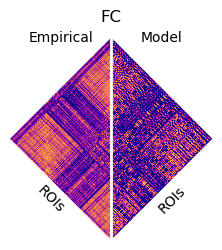

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import Affine2D
from matplotlib.patches import Polygon

# FC_emp and FC_sim are square (n x n) numpy arrays
# Example color limits (change if you like)
vmin, vmax = 0, 1

# We'll place the (0..1, 0..1) image into a square [-1,1]x[-1,1] then rotate 45°
extent = (-1, 1, -1, 1)

fig, ax = plt.subplots(figsize=(2.6,2.6))
ax.set_aspect('equal')
ax.set_axis_off()

# 45° rotation for anything that should align with the matrix axes (images + grid)
rot = Affine2D().rotate_deg(45) + ax.transData

# --- draw left (Empirical) half ---
im_emp = ax.imshow(FC_emp, origin='lower', extent=extent,
                   vmin=vmin, vmax=vmax, cmap='plasma', transform=rot,interpolation='nearest')
# clip to left triangle (x <= 0 in unrotated data coords)

# Y label (left, vertical)
clip_left = Polygon([(-1, 0), (0, 1), (0, -1)], closed=True,
                    facecolor='none', edgecolor='none', transform=ax.transData)
im_emp.set_clip_path(clip_left)

# --- draw right (Model) half ---
im_sim = ax.imshow(FC_sim, origin='lower', extent=extent,
                   vmin=vmin, vmax=vmax, cmap='plasma', transform=rot,interpolation='nearest')

# Y label (left, vertical)
# clip to right triangle (x >= 0)
clip_right = Polygon([(0, -1), (0, 1), (1, 0)], closed=True,
                     facecolor='none', edgecolor='none', transform=ax.transData)
im_sim.set_clip_path(clip_right)

# central separator
ax.plot([0, 0], [-1, 1], color='w', lw=2)

# labels
ax.text(0., 1.2, 'FC', color='k', ha='center', va='center',
        fontsize=12)

ax.text(-0.5, 1.0, 'Empirical', color='k', ha='center', va='center',
        fontsize=10)
ax.text(0.5, 1.0, 'Model', color='k', ha='center', va='center',
        fontsize=10)

# Y-axis label (left center, rotated)
ax.text(-.6, -0.6, 'ROIs', ha='center', va='center',
        fontsize=10, rotation=-45)

# Y-axis label (left center, rotated)
ax.text(0.6, -0.6, 'ROIs', ha='center', va='center',
        fontsize=10, rotation=45)

plt.tight_layout()
#plt.savefig('FC_emp_vs_sim.png',dpi=300, transparent=True)
plt.show()

## Group-level evaluation across fitted subjects

The next cells compute subject-wise empirical and simulated FC/dFC statistics and summarize model fit across the fitted cohort.

Only subjects that have **both**:
- a trained model in `trained_models_{method}`
- a per-subject results file in `ANN_results_{method}`

are included automatically.

If you want to exclude specific fitted subjects, list their indices in `excluded_subject_indices`.

In [13]:
# =============================================================================
# Compute FC and dFC for all fitted subjects
# =============================================================================

FCs_emp = {}
dFCs_emp = {}
FCs_sim = {}
dFCs_sim = {}

for isu, sid in enumerate(fitted):
    sig_path = preproc_dir / f"{sid}_signals.npy"
    inp_path = preproc_dir / f"{sid}_inputs.npy"
    tgt_path = preproc_dir / f"{sid}_targets.npy"
    mdl_path = save_dir / f"{sid}_{method}.pt"

    Z = np.load(sig_path)
    X = np.load(inp_path)
    Y = np.load(tgt_path)

    model = load_model(mdl_path, X, Y)
    Zsim = NPI.model_time_series(model, np.zeros((using_steps, Z.shape[1])), tlen=4600, noise_strength=0.1)

    emp = Z[-test_dur:, :]
    sim = Zsim[-test_dur:, :]

    FCs_emp[isu] = np.corrcoef(emp.T)
    FCs_sim[isu] = np.corrcoef(sim.T)

    dFCs_emp[isu] = dFC(emp)
    dFCs_sim[isu] = dFC(sim)

    del Z, X, Y, model, Zsim, emp, sim
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"Computed FC and dFC summaries for {len(FCs_emp)} fitted subjects.")

Computed FC and dFC summaries for 100 fitted subjects.


In [15]:
# =============================================================================
# Group-level summary metrics
# =============================================================================
example_emp = next(iter(dFCs_emp.values()))
T = example_emp.shape[0]

example_fc = next(iter(FCs_emp.values()))
N = example_fc.shape[0]

tri_N = np.triu_indices(N, 1)
tri_T = np.triu_indices(T, 1)

excluded_subject_indices = [6]
included_subjects = [i for i in sorted(FCs_emp.keys()) if i not in excluded_subject_indices]

Corr_FC_emp_VS_sim = {}
Fluidity_emp = {}
Fluidity_sim = {}

bad_subjects = []

for isu in included_subjects:
    x = np.asarray(FCs_emp[isu][tri_N], dtype=float).ravel()
    y = np.asarray(FCs_sim[isu][tri_N], dtype=float).ravel()

    mask = np.isfinite(x) & np.isfinite(y)
    x_clean = x[mask]
    y_clean = y[mask]

    if len(x_clean) < 2:
        Corr_FC_emp_VS_sim[isu] = np.nan
        bad_subjects.append((isu, "not enough finite FC edges"))
    elif np.std(x_clean) == 0 or np.std(y_clean) == 0:
        Corr_FC_emp_VS_sim[isu] = np.nan
        bad_subjects.append((isu, "constant FC vector"))
    else:
        Corr_FC_emp_VS_sim[isu] = stats.pearsonr(x_clean, y_clean)[0]

    dfc_emp_vals = np.asarray(dFCs_emp[isu][tri_T], dtype=float).ravel()
    dfc_sim_vals = np.asarray(dFCs_sim[isu][tri_T], dtype=float).ravel()

    Fluidity_emp[isu] = np.nanvar(dfc_emp_vals)
    Fluidity_sim[isu] = np.nanvar(dfc_sim_vals)

valid_corrs = [v for v in Corr_FC_emp_VS_sim.values() if np.isfinite(v)]

print(f"Included subjects: {len(included_subjects)}")
print(f"Valid FC correlations: {len(valid_corrs)}")
if len(valid_corrs) > 0:
    print(f"Median FC correlation: {np.median(valid_corrs):.3f}")
else:
    print("Median FC correlation: NaN")

if bad_subjects:
    print("\nSubjects with FC issues:")
    for s in bad_subjects:
        print(s)

C:\Users\tomas\AppData\Local\Temp\ipykernel_25096\4111372465.py:43: RuntimeWarning: Degrees of freedom <= 0 for slice.
  Fluidity_sim[isu] = np.nanvar(dfc_sim_vals)


Included subjects: 99
Valid FC correlations: 97
Median FC correlation: 0.620

Subjects with FC issues:
(8, 'not enough finite FC edges')
(57, 'not enough finite FC edges')
